# Test the gaussianity of a map

On veut évaluer à quel point une carte $S$ est non gaussienne. Pour cela, on construit une carte $S'$ qui a le même spectre de puissance que la carte $S$ mais qui est gaussienne puis on compare les stats de $S$ et $S'$.

Pour construire $S'$, on utilise une carte de bruit blanc.



In [1]:
%matplotlib notebook

from jax import jit, config, grad
config.update("jax_enable_x64", True)

import numpy as np
import healpy as hp
from matplotlib import pyplot as plt
from importlib import reload
import pynkowski as mf   # For Minkowski Functionals
#import camb

import scatcovjax.Sphere_lib as sphlib
import scatcovjax.Synthesis_lib as synlib
import scatcovjax.Fast_scattering_lib as scatlib
from s2wav.filter_factory.filters import filters_directional_vectorised

import s2wav
import s2fft

import scatcovjax.plotting as plot
plot.notebook_plot_format()

In [2]:
import jaxlib
jaxlib.__file__

'/obs/lmousset/miniconda3/envs/jax/lib/python3.10/site-packages/jaxlib/__init__.py'

In [3]:
import jax
# Check we're running on GPU
from jax.lib import xla_bridge
print(xla_bridge.get_backend().platform)

gpu


# Test the regularisation 

$I = \log(I+\varepsilon)$

In [4]:
L=256

In [5]:
def get_hist_envelop(f, bins=100, range=(-10, 10), density=False):
    hist, bins_edges = np.histogram(f, bins=bins, range=range, density=density) 
    bins_centers = (bins_edges[:-1] + bins_edges[1:]) / 2  # Bin centers
    
    return bins_centers, hist

## LSS map

In [122]:
nside = int(L / 2)

### Get the Healpix map
# Get all the maps sort by redshift
run=0
dirmap = '/travail/lmousset/CosmoGrid/CosmoFiducial_barionified_nside512/'
data_LSS = np.load(dirmap + f'baryonified_shells_run{run:04}.npz')
shell_info, shells = sphlib.sort_CosmoGrid_maps(data_LSS)
# Take the map
idx_z = 10
I = shells[idx_z, :]
z = sphlib.get_mean_redshift(shell_info)[idx_z]
print(f'Map at redshift {z=}')
# From nside=512 to nside=L/2

I = hp.ud_grade(I, nside_out=nside)


# Get the filtered Hpx map
f_target, flm_target = sphlib.make_CosmoGrid_sky(L, dirmap=dirmap, run=0, idx_z=10, sampling='healpix',
                                                    nest=False, normalize=True, reality=True)


Map at redshift z=0.14677950739860535
Map at redshift z=0.14677950739860535
Mean and STD: -0.000 and 1.000


<IPython.core.display.Javascript object>


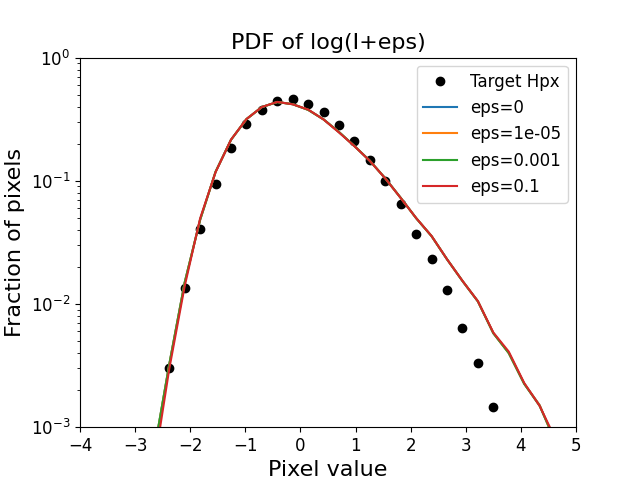

Mean and STD: -0.000 and 1.000
Mean and STD: 0.000 and 1.000
Mean and STD: -0.000 and 1.000
Mean and STD: 0.000 and 1.000


Text(0.5, 1.0, 'PDF of log(I+eps)')

In [123]:
plt.figure()
bc, hist = get_hist_envelop(f_target, bins=50, range=(-7, 7), density=True)
plt.plot(bc, hist, 'ko', label=f'Target Hpx')
    
for eps in [0, 1e-5, 1e-3, 1e-1]:
    # Take the log
    Ilog = np.log(I + eps)
    Ilog = sphlib.normalize_map(Ilog)
    bc, hist = get_hist_envelop(Ilog, bins=50, range=(-7, 7), density=True)
    plt.plot(bc, hist, label=f'{eps=}')
plt.legend(fontsize=12)
plt.ylim(1e-3, 1)
plt.xlim(-4, 5)
plt.yscale('log')
plt.xlabel('Pixel value')
plt.ylabel('Fraction of pixels')
plt.title('PDF of log(I+eps)')

Mean and STD: 0.000 and 1.000


<IPython.core.display.Javascript object>


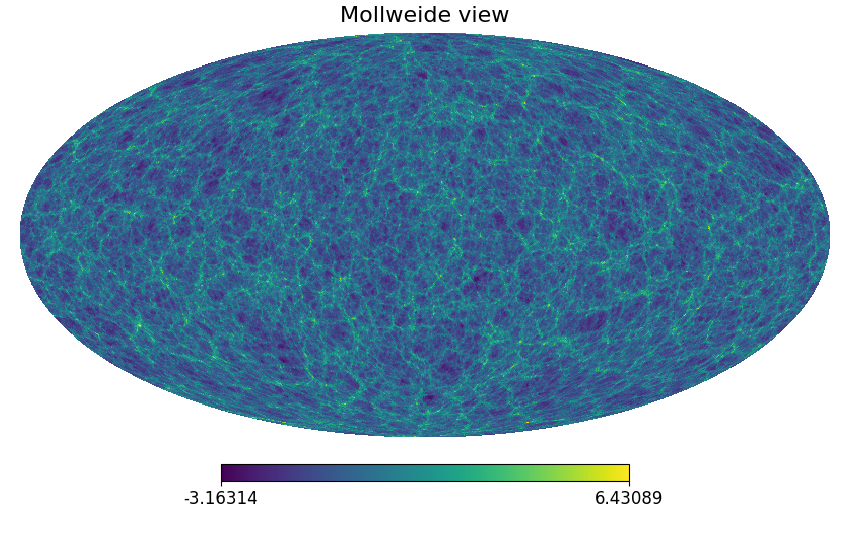

In [106]:
Ilog = np.log(I + 1e-6)
Ilog = sphlib.normalize_map(Ilog)
hp.mollview(Ilog)

## Lensing and tSZ map

In [6]:
from astropy.io import fits
nside = int(L / 2)

### Get the Healpix map
sky = 'lensing'
if sky == 'lensing':
    mapfile = '/travail/lmousset/Ulagam/kappa_00099.fits'
elif sky == 'tsz':
     mapfile = '/travail/lmousset/NASAsimu/tSZ_skymap_healpix_nopell_Nside4096_y_tSZrescale0p75.fits'
image_file = fits.open(mapfile)
I = hp.read_map(image_file, 0, h=False)

# From nside=4096 to nside=L/2
I = hp.ud_grade(I, nside_out=nside)

# Get the filtered Hpx map
f_target, flm_target = sphlib.make_NASAsimu_sky(L, mapfile=mapfile, sampling='Healpix',
                                                    nest=False, normalize=True, reality=True, sky=sky)

Mean and STD: 0.000 and 1.000


<IPython.core.display.Javascript object>


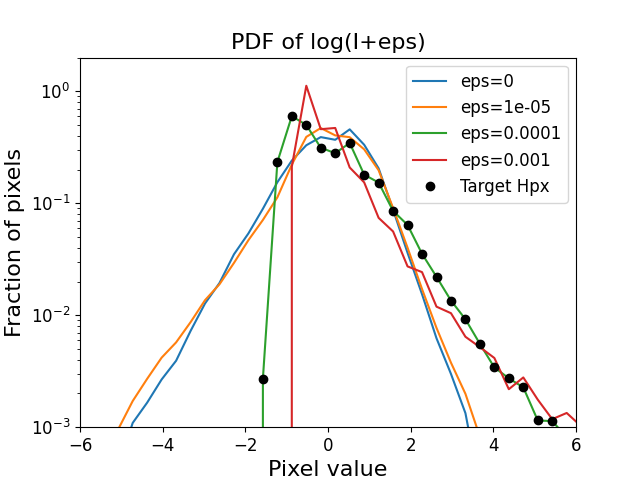

Mean and STD: nan and nan
Mean and STD: nan and nan
Mean and STD: 0.000 and 1.000
Mean and STD: 0.000 and 1.000


Text(0.5, 1.0, 'PDF of log(I+eps)')

In [12]:
plt.figure()

for eps in [0, 1e-5, 1e-4, 1e-3]:
    # Take the log
    Ilog = np.log(I + eps)
    Ilog = sphlib.normalize_map(Ilog)
    bc, hist = get_hist_envelop(Ilog, bins=40, range=(-7, 7), density=True)
    plt.plot(bc, hist, label=f'{eps=}')
    
bc, hist = get_hist_envelop(f_target, bins=40, range=(-7, 7), density=True)
plt.plot(bc, hist, 'ko', label=f'Target Hpx')

plt.legend(fontsize=12, loc='upper right')
plt.ylim(1e-3, 2)
plt.xlim(-6, 6)
plt.yscale('log')
plt.xlabel('Pixel value')
plt.ylabel('Fraction of pixels')
plt.title('PDF of log(I+eps)')


<IPython.core.display.Javascript object>


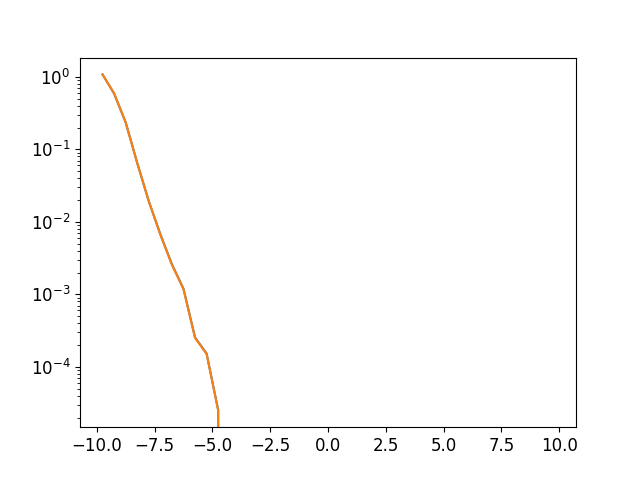

In [45]:
plt.figure()
bc, hist = get_hist_envelop(np.log(I-np.min(I)), bins=40, density=True)
plt.plot(bc, hist, label=f'{eps=}')
bc, hist = get_hist_envelop(np.log(I-np.min(I)+1e-6), bins=40, density=True)
plt.plot(bc, hist, label=f'{eps=}')
plt.yscale('log')
#plt.xscale('log')

<IPython.core.display.Javascript object>


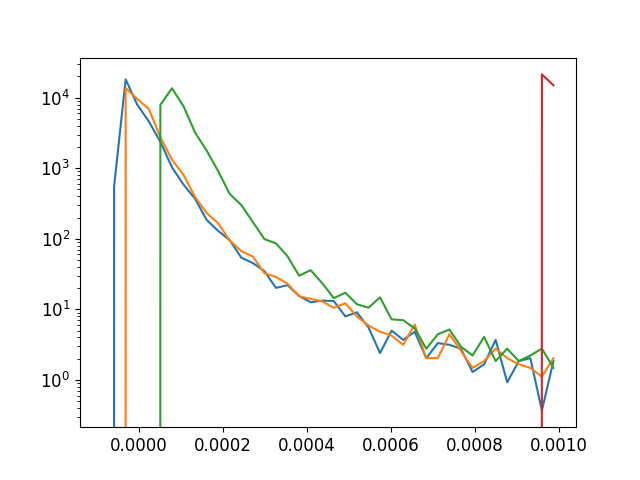

In [31]:
plt.figure()
for eps in [0, 1e-5, 1e-4, 1e-3]:
    bc, hist = get_hist_envelop(I+eps, bins=40, range=(-1e-4, 1e-3), density=True)
    plt.plot(bc, hist, label=f'{eps=}')
plt.yscale('log')
 

-5.1149727e-05 0.008589098
-9.926751 -4.745686


<IPython.core.display.Javascript object>


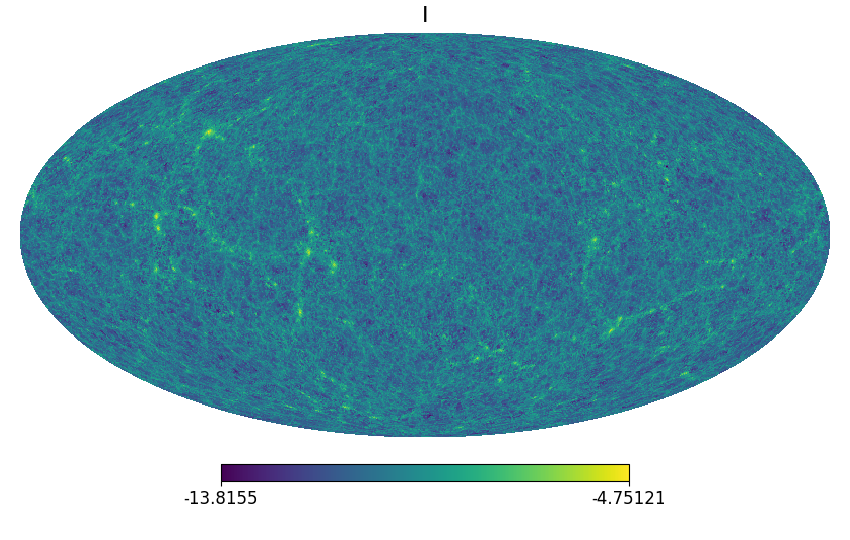

<IPython.core.display.Javascript object>


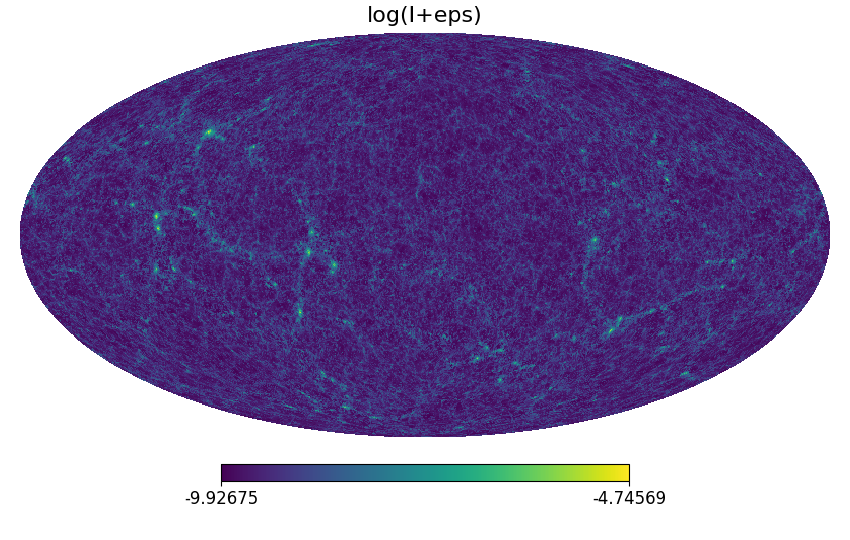

In [41]:
print(np.min(I), np.max(I))
Ilog = np.log(I + 1e-4)
print(np.min(Ilog), np.max(Ilog))
#Ilog = sphlib.normalize_map(Ilog)
hp.mollview(np.log(I-np.min(I)+1e-6), title='I')
hp.mollview(Ilog, title='log(I+eps)')

# Planar map

Map at redshift z=0.14677950739860535
Mean and STD: 0.000 and 1.000


<IPython.core.display.Javascript object>


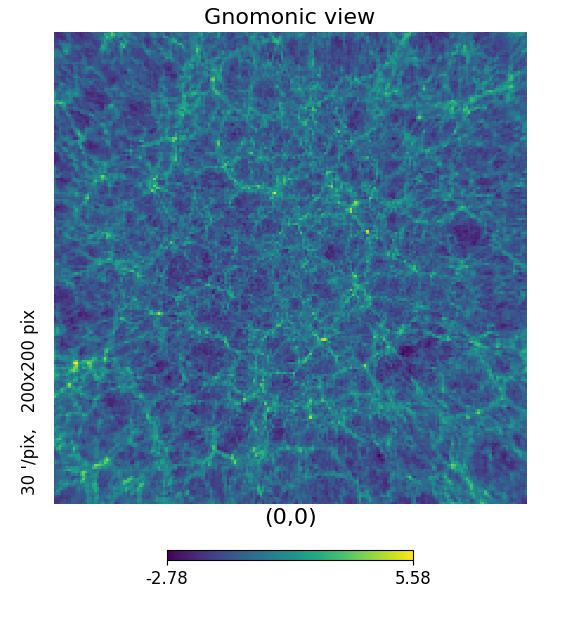

In [4]:
### Build a flat map with structures
repo = '/travail/lmousset/CosmoGrid/CosmoFiducial_barionified_nside512/'
f_target, flm_target = sphlib.make_CosmoGrid_sky(L=512, dirmap=repo, run=0, idx_z=10, sampling='healpix', 
                                   nest=False, normalize=True, reality=True)
#hp.mollview(f_target)
S = hp.gnomview(f_target, reso=30, return_projected_map=True)



In [ ]:
S = np.random.randn(200, 200)

<IPython.core.display.Javascript object>


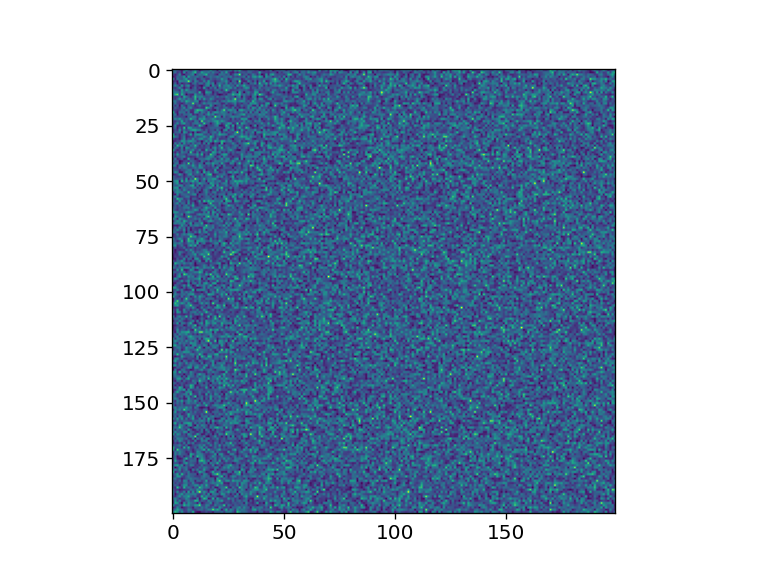

In [28]:
### Fourier transform

ft_S = np.fft.fftshift(np.fft.fft2(S))
plt.figure()
plt.imshow(np.abs(ft_S))


[[-2.00029901e+00  1.01192503e-01 -1.90299749e-01 ... -4.70700321e-01
  -1.84374998e-01  6.13122354e-01]
 [ 7.07248826e-01  9.42937123e-01  1.34114690e+00 ... -1.20704851e-01
  -6.64715847e-01 -1.43712379e-01]
 [ 1.76437722e-01 -8.12081087e-01 -2.97118041e+00 ... -6.76085414e-02
  -1.31527980e+00  1.21341793e+00]
 ...
 [ 5.73363063e-02 -1.68173711e+00 -7.50613466e-01 ... -8.00213979e-01
  -4.80712248e-01  8.31180938e-01]
 [-1.34364755e-03  1.29601476e+00  9.90601331e-01 ... -1.70900412e-01
   9.36434106e-01  9.56175615e-01]
 [-3.90093718e-02  3.75775174e-01  2.47299661e-01 ... -6.24237926e-01
   1.38802372e+00 -1.49405558e+00]]


<IPython.core.display.Javascript object>


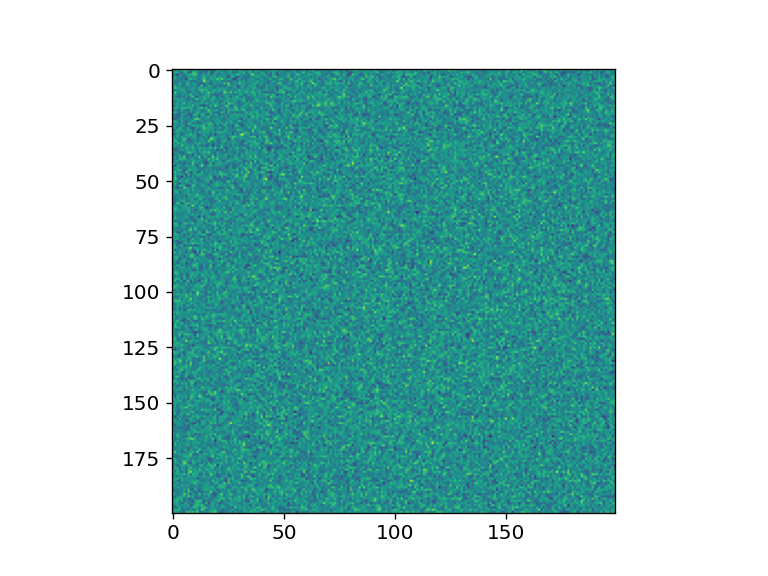

In [29]:
### White noise
wn = np.random.randn(200, 200)
ft_wn = np.fft.fftshift(np.fft.fft2(wn))
print(wn)

plt.figure()
plt.imshow(wn)

In [30]:
### Make S'
# TF(S') = |TF(S)| x TF(wn) / | TF(wn)|

ft_Sprime = np.abs(ft_S) * ft_wn / np.abs(ft_wn)

Sprime = np.fft.ifft2(np.fft.fftshift(ft_Sprime))

In [6]:
Sprime

array([[ 1.51029447-4.62683707e-16j,  1.19609428-3.65065300e-16j,
         0.87370815+8.85021607e-18j, ...,  1.46674489-3.31630433e-16j,
         1.02007143-3.93541954e-16j,  0.70309309-5.28907375e-17j],
       [ 2.41015235+1.42093407e-16j,  1.76632034-4.60893922e-16j,
         1.59175058+1.23530478e-16j, ...,  0.91335415+1.25606714e-15j,
         1.29908788-3.29766944e-16j,  1.60590598-1.54935040e-16j],
       [ 1.53023046-5.41216339e-17j,  0.79853732-1.42348244e-17j,
         1.41920228+6.65818133e-17j, ...,  1.01467398-1.53994749e-16j,
        -1.59081841+2.90355430e-16j, -0.15814988+3.99967697e-19j],
       ...,
       [ 0.03495547-7.26304281e-16j,  0.44962892-1.65082344e-16j,
         1.5832232 -9.33233451e-16j, ...,  0.49520122+6.25333801e-16j,
         2.41480473+5.26857311e-16j,  1.69370748-3.80612290e-16j],
       [ 1.38653612-1.45340947e-16j,  0.06132422-8.25952568e-16j,
         0.86737096-7.54623493e-18j, ...,  1.35894446-1.25265070e-16j,
         2.58049118-1.77691695e-16j

<IPython.core.display.Javascript object>


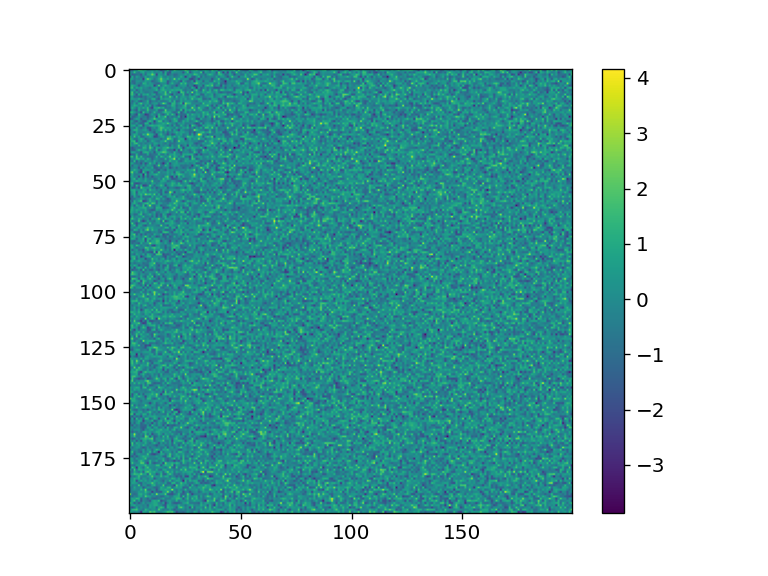

In [32]:
plt.figure()
plt.imshow(np.real(Sprime))
plt.colorbar()

<IPython.core.display.Javascript object>


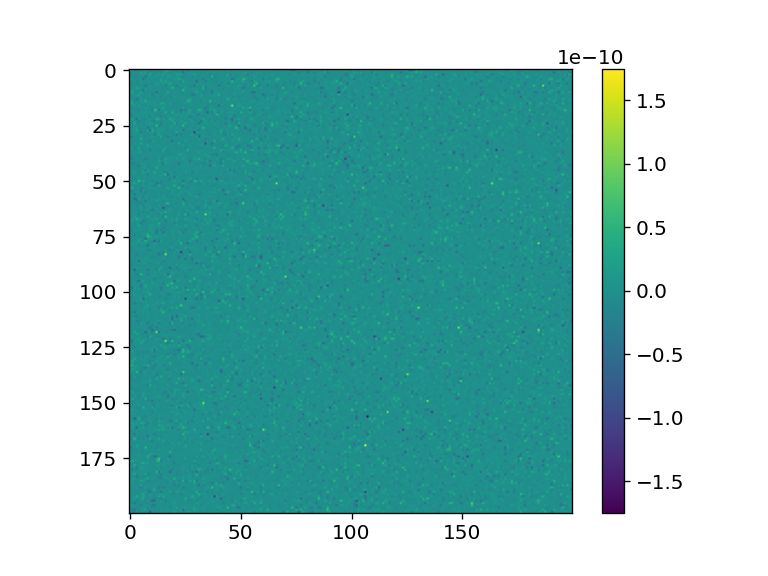

In [33]:
### Check the PS
ps_S = np.abs(ft_S)**2
ps_Sprime = np.abs(ft_Sprime)**2

plt.figure()
plt.imshow(ps_S - ps_Sprime)
plt.colorbar()

<IPython.core.display.Javascript object>


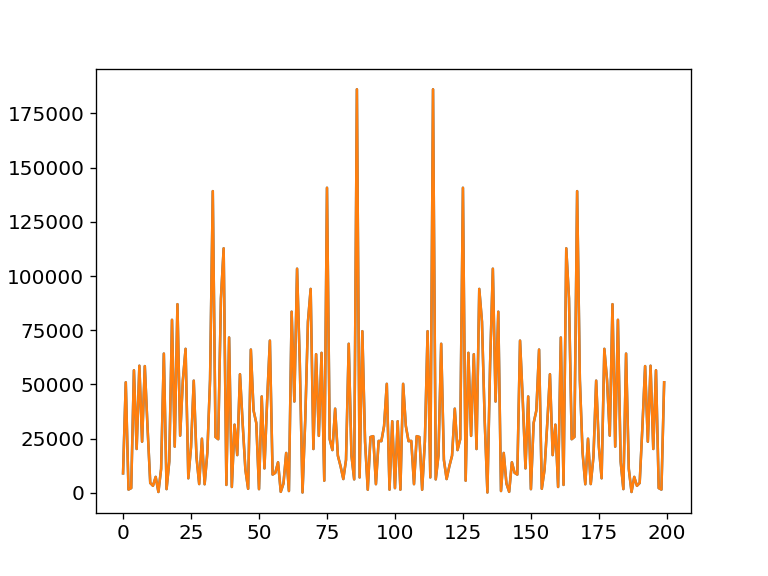

In [34]:
plt.figure()
plt.plot(ps_S[100, :])
plt.plot(ps_Sprime[100, :])

<IPython.core.display.Javascript object>


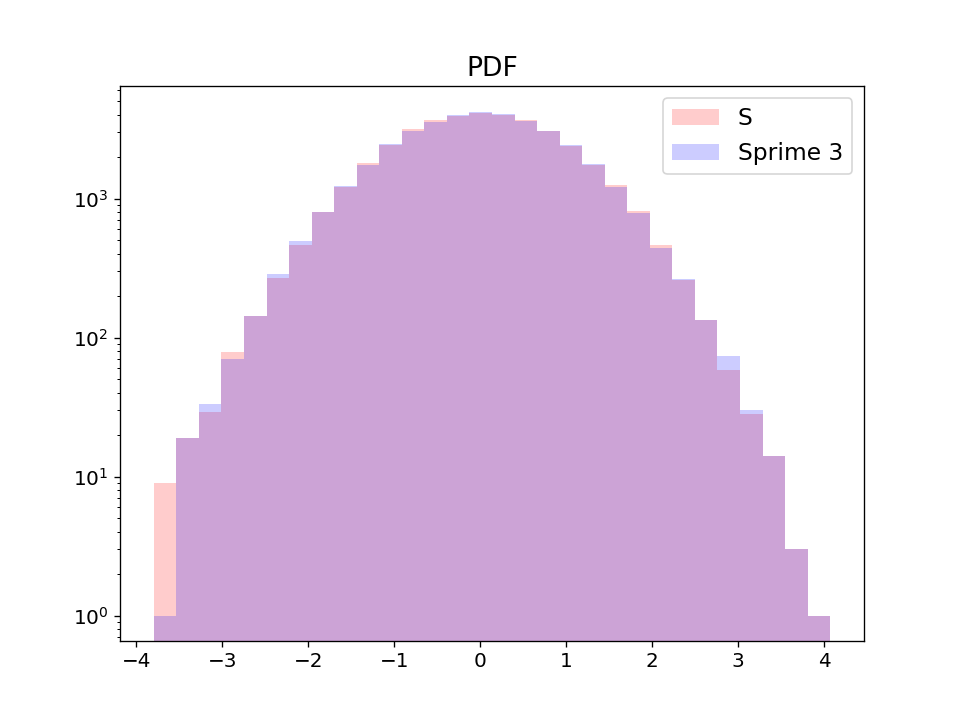

In [38]:
fig, ax0 = plt.subplots(1, 1, figsize=(8, 6))


ax0.hist(S.ravel(), bins=30, range=(S.min(), S.max()), 
         density=False, color='r', alpha=0.2, label=f'S')
ax0.hist(Sprime.ravel(), bins=30, range=(S.min(), S.max()), 
         density=False, color='b', alpha=0.2, label=f'Sprime')
ax0.set_title('PDF')
ax0.set_yscale("log")
#ax0.set_ylim(10, 2e5)
ax0.legend()

# Spherical maps: Gaussian realisations

Make Gaussian realisation with phase randomisation

In [4]:
import s2wav
sampling = "mw"
multiresolution = True
reality = True

L = 128
nside = L//2
N = 3
J_min = 2
lam = 2.0#np.sqrt(2)
delta_j = 5

if reality:
    M = L
else:
    M = 2 * L - 1

J_max = s2wav.utils.shapes.j_max(L, lam=lam)
J = J_max - J_min + 1
print(f'{J=} {J_max=}')

J=6 J_max=7


## Get a standard sky

Here I load the maps I decided to use for the paper. 

In [5]:
reload(sphlib)
### SKY
sky = 'cmb'

if sky == 'lss':
    repo = '/travail/lmousset/CosmoGrid/CosmoFiducial_barionified_nside512/'
    S, Slm = sphlib.make_CosmoGrid_sky(L, dirmap=repo, run=0, idx_z=10, sampling=sampling,
                                                    nest=False, normalize=True, reality=reality)
elif sky == 'cmb':
    S, Slm  = sphlib.make_pysm_sky(L, 'cmb', sampling=sampling, nest=False,
                                                normalize=True, reality=reality)
elif sky == 'tsz':
    mapfile = '/travail/lmousset/NASAsimu/tSZ_skymap_healpix_nopell_Nside4096_y_tSZrescale0p75.fits'
    S, Slm  = sphlib.make_NASAsimu_sky(L, mapfile=mapfile, sampling=sampling,
                                                    nest=False, normalize=True, reality=reality, sky=sky)
elif sky == 'lensing':
    mapfile = '/travail/lmousset/Ulagam/kappa_00099.fits'
    S, Slm  = sphlib.make_NASAsimu_sky(L, mapfile=mapfile, sampling=sampling,
                                                    nest=False, normalize=True, reality=reality, sky=sky)
elif sky == 'venus':
    S, Slm  = sphlib.make_planet(L, 'venus', normalize=True, reality=reality)
else:
    raise ValueError('sky must be in lss, cmb, tsz, lensing, venus.')

if reality:
    Slm = sphlib.make_flm_full(Slm, L)

Mean and STD: 0.000 and 1.000
Mean and STD: 0.077 and 0.844


## Others maps

NASA map downloaded at https://lambda.gsfc.nasa.gov/simulation/full_sky_sims_ov.html

Maps are provided in Healpix format, Nside=4096

- CIB at 27, 100 and 353 GHz
- Radio Sources at 27, 100 and 353 GHz
- CMB lensing convergence
- Lensed CMB
- kSZ
- tSZ

In [ ]:
### Load a fits image from NASA
#from astropy.io import fits
#from astropy.utils.data import get_pkg_data_filename

### CMB
#image_file = get_pkg_data_filename('/travail/lmousset/NASAsimu/148_unlensedcmb_healpix.fits')

### CIB
#image_file = get_pkg_data_filename('/travail/lmousset/NASAsimu/100_ir_pts_healpix_nopell_Nside4096_DeltaT_uK_lininterp_CIBrescale0p75.fits')

### Radio Sources
#image_file = fits.open('/travail/lmousset/NASAsimu/353_rad_pts_healpix_nopell_Nside4096_DeltaT_uK_fluxcut148_7mJy_lininterp.fits')

### kSZ
#image_file = get_pkg_data_filename('/travail/lmousset/NASAsimu/148_ksz_healpix_nopell_Nside4096_DeltaT_uK.fits')

### tSZ
#image_file = get_pkg_data_filename('/travail/lmousset/NASAsimu/tSZ_skymap_healpix_nopell_Nside4096_y_tSZrescale0p75.fits')

### CMB lensing convergence
#image_file = get_pkg_data_filename('/travail/lmousset/NASAsimu/healpix_4096_KappaeffLSStoCMBfullsky.fits')

### Lensed CMB
#image_file = get_pkg_data_filename('/travail/lmousset/NASAsimu/Sehgalsimparams_healpix_4096_KappaeffLSStoCMBfullsky_phi_SimLens_Tsynfastnopell_fast_lmax8000_nside4096_interp2.5_method1_1_lensed_map.fits')


S = hp.read_map(image_file, 0, h=False)
S = hp.ud_grade(S, nside_out=nside)
S = sphlib.normalize_map(S)
#hp.mollview(S, min=None, max=None, title='S')

### Get the Slm
S_lm = s2fft.forward_jax(S, L=L, nside=nside, reality=True, sampling='healpix')

### Inverse transform to kill small scales and have same power in S and Slm
S = s2fft.inverse_jax(S_lm, L=L, nside=nside, reality=True, sampling='healpix')


##  Make the gaussian realisations S'

In [6]:
nside = L // 2
npix = 12*nside**2
ngauss = 50 # Number of gaussian realisations
WN = np.zeros((ngauss, npix), dtype=np.float64)
WN_lm, flm_gauss = np.zeros((ngauss, L, 2*L-1), dtype=np.complex128), np.zeros((ngauss, L, 2*L-1), dtype=np.complex128)

for n in range(ngauss):
    print(n)
    WN[n, :] = np.random.randn(npix)
    WN_lm[n, :] = s2fft.forward_jax(WN[n], L=L, nside=nside, reality=reality, sampling='healpix')
    flm_gauss[n, :] = np.abs(Slm) * WN_lm[n] / np.abs(WN_lm[n])
  

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


<IPython.core.display.Javascript object>


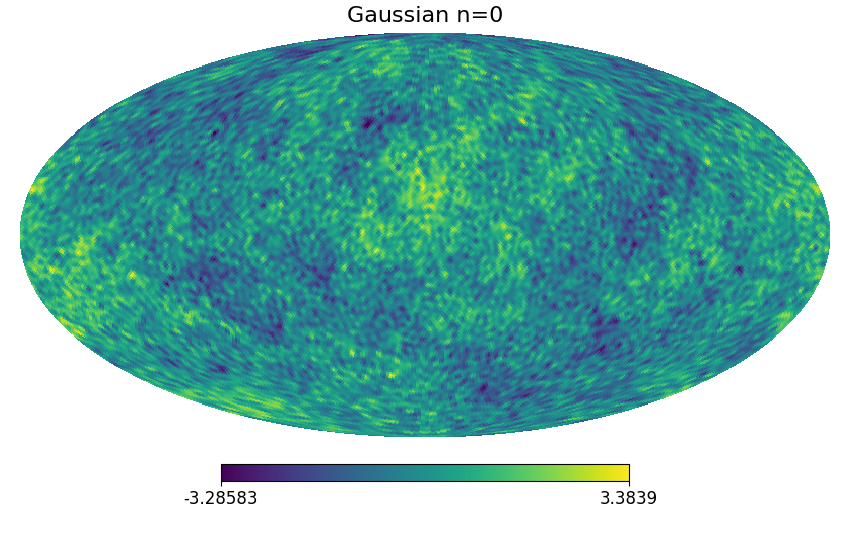

In [8]:
# Look at one map in Hpx
n=0
f_gauss_hpx = s2fft.inverse_jax(flm_gauss[n], L=L, nside=nside, reality=reality, sampling='healpix')

hp.mollview(f_gauss_hpx, title=f'Gaussian n={n}')

# Gaussian realisations using synfast/anafast 

In [41]:
f_gauss

array([-0.751624  , -0.41452374,  0.31751363, ...,  1.25346701,
        1.84066593,  0.95427764])

In [ ]:
### Make a map in Healpix
S, _  = sphlib.make_pysm_sky(L, 'cmb', sampling='healpix', nest=False, normalize=True, reality=True)

### Get the Slm explicitely using S2FFT
Slm = s2fft.forward_jax(S, L=L, nside=nside, reality=True, sampling='healpix')
#Slm = Slm[:, L - 1:] 
print(Slm.shape)
ps_S = sphlib.compute_ps(Slm, reality=False)

### Get the Cl with anafast
Cl = hp.anafast(np.array(S), lmax=L-1, pol=False)
print(Cl.shape)

### Make Gaussian realisations
ngauss = 50
flm_gauss = np.zeros((ngauss, L, 2*L-1),  dtype=np.complex128)
allps_gauss = np.zeros((ngauss, L))
Cl_gauss = np.zeros((ngauss, L))
for n in range(ngauss):
    f_gauss = hp.synfast(Cl, nside=nside, lmax=L-1, pol=False)
    Cl_gauss[n, :] = hp.anafast(f_gauss, lmax=L-1, pol=False)
    
    flm_gauss[n, :, :] = s2fft.forward_jax(f_gauss, L=L, nside=nside, reality=True, sampling='healpix')
    allps_gauss[n, :] = sphlib.compute_ps(flm_gauss[n], reality=False)

### Mean and STD
mean_Cl_gauss = np.mean(Cl_gauss, axis=0)
mean_ps_gauss = np.mean(allps_gauss, axis=0)
std_ps_gauss = np.std(allps_gauss, axis=0)   
    
## Plot
plt.figure()
ll = np.arange(L)
plt.plot(ll, ps_S, 'b', label="PS(S)")
plt.plot(ll, Cl, 'ko', label="Cl of S")
plt.plot(ll, mean_Cl_gauss, 'g', label="Cl of Sgauss")
plt.plot(ll, mean_ps_gauss, 'r', label="PS(Sgauss)")
plt.fill_between(ll, mean_ps_gauss - std_ps_gauss, mean_ps_gauss + std_ps_gauss, color='r', alpha=0.3)
plt.yscale("log")
plt.xscale("log", base=10)
plt.ylim(1e-5, 5e-1)
plt.legend()

Mean and STD: 0.000 and 1.000
(128, 255)
(128,)


# Compare the stats on S and Sprime

## P00


<IPython.core.display.Javascript object>


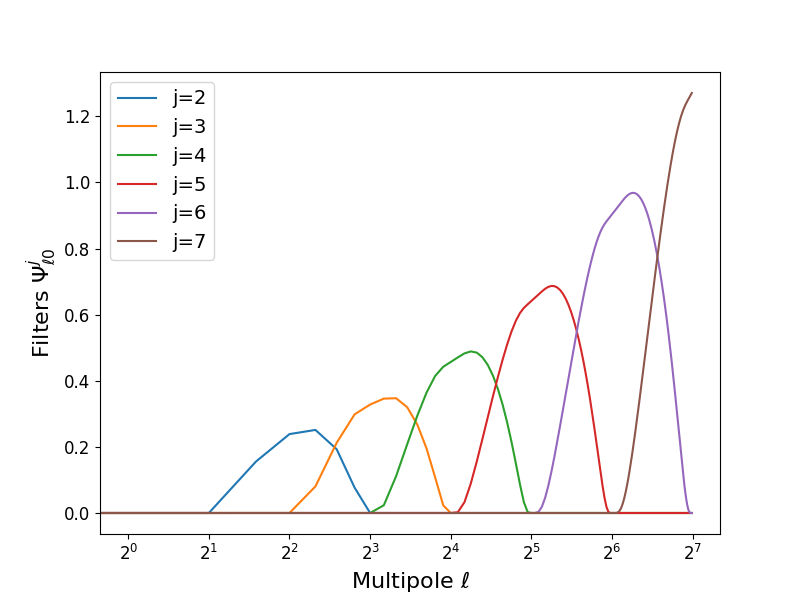


============ Wigner precomputes ===============


In [59]:
#Make the filters
filters = filters_directional_vectorised(L, N, J_min, lam=lam)
plot.plot_filters(filters, J_min=J_min, J_max=J_max, real=True, m=L-1)
# Take the wavelets only, not the scaling function
filters = filters[0]  


# Weights and precomps
weights = scatlib.quadrature(L, J_min, lam, sampling, None, multiresolution)

#precomps = s2wav.transforms.jax_wavelets.generate_wigner_precomputes(L, N, J_min, lam, sampling, None, False,
 #                                                                    reality, multiresolution)

print('\n============ Wigner precomputes ===============')
precomps = scatlib.generate_full_precompute(L=L,
                                    N=N,
                                    J_min=J_min,
                                    lam=lam,
                                    sampling=sampling,
                                    reality=False,
                                    multiresolution=multiresolution,
                                    nside=None)

In [61]:
### P00 of the map S
P00 = scatlib.get_P00only(Slm, L, N, J_min, lam, sampling, nside,
                          reality=False, multiresolution=True, for_synthesis=True, normalisation=None,
                          filters=filters, quads=weights, precomps=precomps)  # [J][Norient]

allP00gauss = []
for n in range(ngauss):
    allP00gauss.append(scatlib.get_P00only(np.nan_to_num(flm_gauss[n, :, :]), L, N, J_min, lam, sampling, nside=None,
                              reality=False, multiresolution=True, for_synthesis=True, normalisation=None,
                              filters=filters, quads=weights, precomps=precomps))  # [J][Norient]


<IPython.core.display.Javascript object>


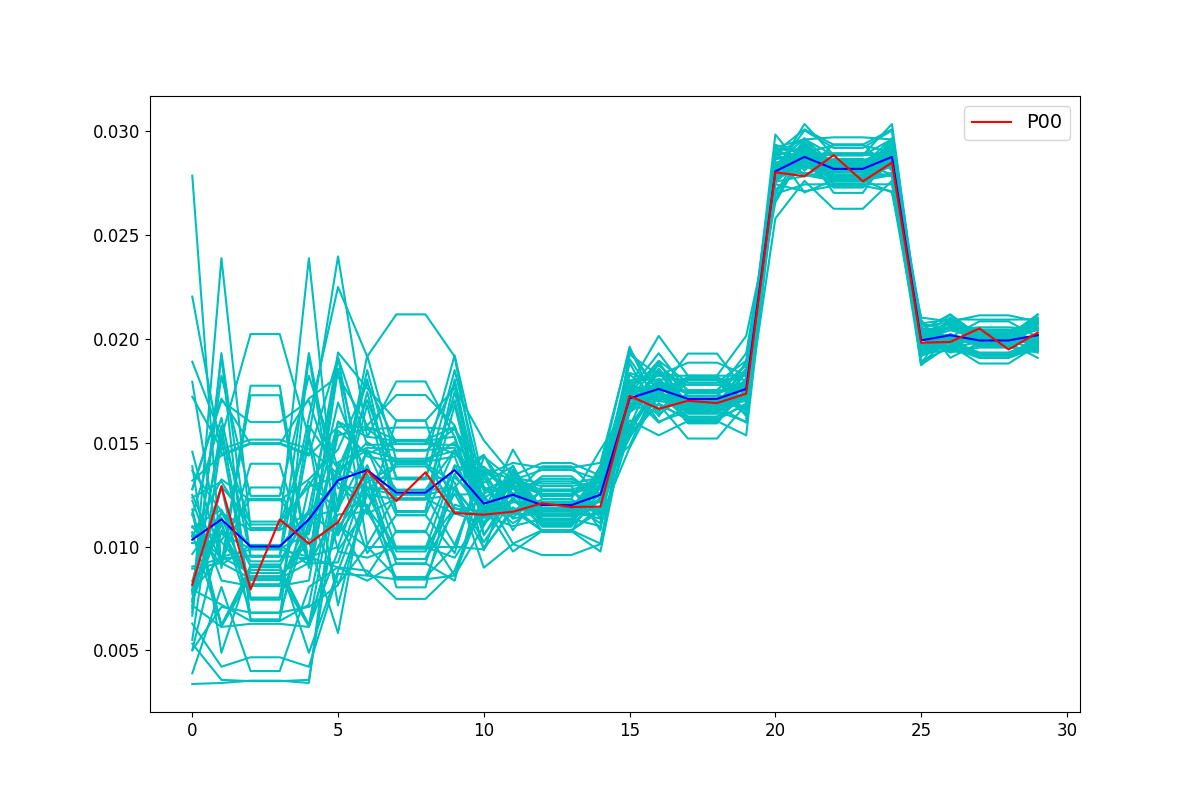

In [62]:
plt.figure(figsize=(12, 8))

for n in range(ngauss):
    plt.plot(allP00gauss[n].ravel(), 'c')
plt.plot(np.mean(allP00gauss, axis=0).ravel(), 'b')

plt.plot(P00.ravel(), 'r', label='P00')
plt.legend()

<IPython.core.display.Javascript object>


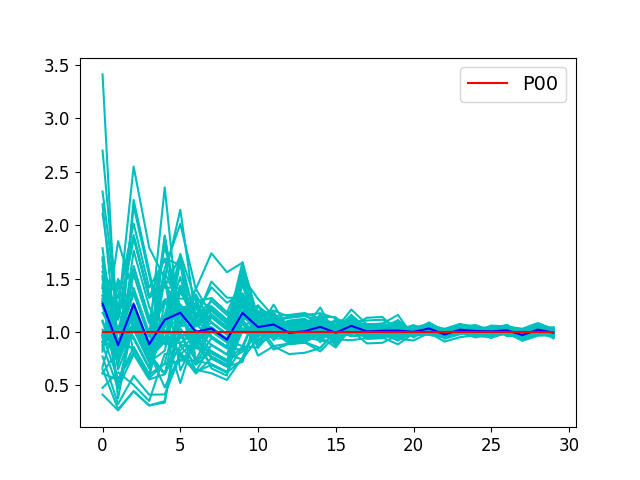

In [63]:
plt.figure()

for n in range(ngauss):
    plt.plot(allP00gauss[n].ravel()/ P00.ravel(), 'c')

plt.plot(np.mean(allP00gauss, axis=0).ravel() /P00.ravel() , 'b')
#plt.plot(P00prime.ravel()/P00.ravel(), 'blue', label='P00 Gauss')
plt.plot(P00.ravel() / P00.ravel(), 'red', label='P00')
plt.legend()

## Histogram

In [66]:
f_gauss

array([-0.751624  , -0.41452374,  0.31751363, ...,  1.25346701,
        1.84066593,  0.95427764])

<IPython.core.display.Javascript object>


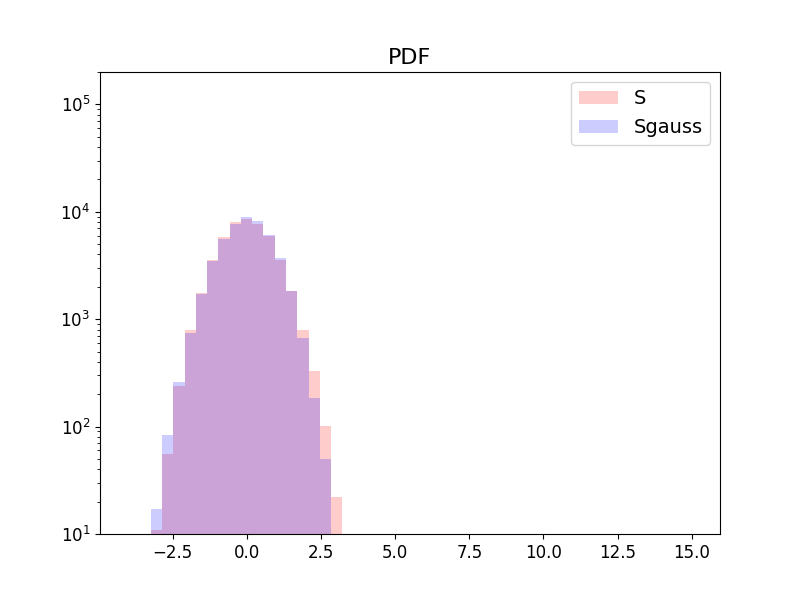

In [70]:
fig, ax0 = plt.subplots(1, 1, figsize=(8, 6))

histrange=(-4, 15)

ax0.hist(S, bins=50, range=histrange, 
         density=False, color='r', alpha=0.2, label=f'S')
ax0.hist(f_gauss, bins=50, range=histrange, 
         density=False, color='b', alpha=0.2, label=f'Sgauss')
#ax0.hist(WN[r], bins=30, range=(S.min(), S.max()), 
 #        density=False, color='g', alpha=0.2, label=f'WN {r}')
ax0.set_title('PDF')
ax0.set_yscale("log")
ax0.set_ylim(10, 2e5)
ax0.legend()

## Minkowski

In [14]:
def make_minkowski(us, map_hpx):

    data = mf.Healpix(map_hpx, normalise=True, mask=None)     # Default parameters
    v0 = mf.V0(data, us)
    v1 = mf.V1(data, us)
    v2 = mf.V2(data, us)
    
    return v0, v1, v2

In [15]:
us = np.arange(-5., 7.01, 0.1)

v0_S, v1_S, v2_S = make_minkowski(us, np.array(S))

v0_Sprime, v1_Sprime, v2_Sprime = np.zeros((nreals, us.size)), np.zeros((nreals, us.size)), np.zeros((nreals, us.size))
v0_WN, v1_WN, v2_WN = np.zeros((nreals, us.size)), np.zeros((nreals, us.size)), np.zeros((nreals, us.size))

for r in range(nreals):
    v0_Sprime[r], v1_Sprime[r], v2_Sprime[r] = make_minkowski(us, np.array(np.real(Sprime[r])))
    v0_WN[r], v1_WN[r], v2_WN[r] = make_minkowski(us, WN[r])

  0%|          | 0/121 [00:00<?, ?it/s]

  0%|          | 0/121 [00:00<?, ?it/s]

  0%|          | 0/121 [00:00<?, ?it/s]

  0%|          | 0/121 [00:00<?, ?it/s]

  0%|          | 0/121 [00:00<?, ?it/s]

...

  0%|          | 0/121 [00:00<?, ?it/s]

  0%|          | 0/121 [00:00<?, ?it/s]

  0%|          | 0/121 [00:00<?, ?it/s]

  0%|          | 0/121 [00:00<?, ?it/s]

  0%|          | 0/121 [00:00<?, ?it/s]

In [16]:
mean_v0_Sprime = np.mean(v0_Sprime, axis=0)
mean_v1_Sprime = np.mean(v1_Sprime, axis=0)
mean_v2_Sprime = np.mean(v2_Sprime, axis=0)

mean_v0_WN = np.mean(v0_WN, axis=0)
mean_v1_WN = np.mean(v1_WN, axis=0)
mean_v2_WN = np.mean(v2_WN, axis=0)

std_v0_Sprime = np.std(v0_Sprime, axis=0)
std_v1_Sprime = np.std(v1_Sprime, axis=0)
std_v2_Sprime = np.std(v2_Sprime, axis=0)

std_v0_WN = np.std(v0_WN, axis=0)
std_v1_WN = np.std(v1_WN, axis=0)
std_v2_WN = np.std(v2_WN, axis=0)

<IPython.core.display.Javascript object>


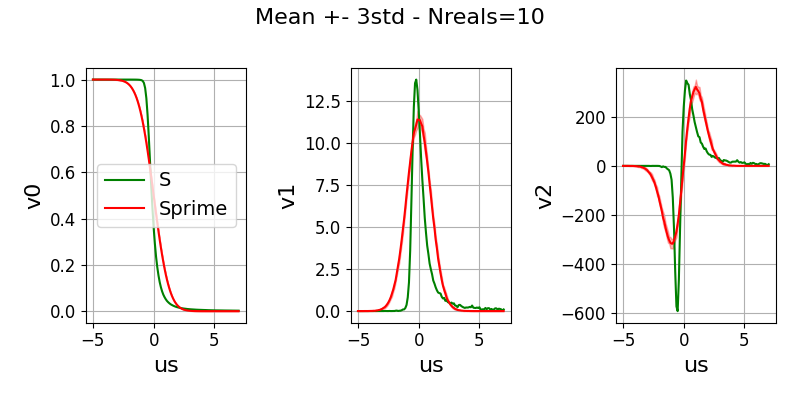

In [17]:
ns = 3 # Number of STD for the plot

fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(8, 4))
fig.suptitle(f'Mean +- {ns}std - Nreals={nreals}')

ax0.plot(us, v0_S, color='g', label='S')
#ax0.plot(us, mean_v0_WN, 'b', label="WN")
#ax0.fill_between(us, mean_v0_WN - ns*std_v0_WN, mean_v0_WN + ns*std_v0_WN, color='b', alpha=0.3)
ax0.plot(us, mean_v0_Sprime, 'r', label="Sprime")
ax0.fill_between(us, mean_v0_Sprime - ns*std_v0_Sprime, mean_v0_Sprime + ns*std_v0_Sprime, color='r', alpha=0.3)
ax0.set_xlabel('us')
ax0.set_ylabel('v0')
ax0.grid()
ax0.legend()

ax1.plot(us, v1_S, 'g', label='S')
#ax1.plot(us, mean_v1_WN, 'b', label="WN")
#ax1.fill_between(us, mean_v1_WN - ns*std_v1_WN, mean_v1_WN + ns*std_v1_WN, color='b', alpha=0.3)
ax1.plot(us, mean_v1_Sprime, 'r', label="Sprime")
ax1.fill_between(us, mean_v1_Sprime - ns*std_v1_Sprime, mean_v1_Sprime + ns*std_v1_Sprime, color='r', alpha=0.3)
ax1.set_xlabel('us')
ax1.set_ylabel('v1')
ax1.grid()
#ax1.legend()

ax2.plot(us, v2_S, color='g', label='S')
#ax2.plot(us, mean_v2_WN, 'b', label="WN")
#ax2.fill_between(us, mean_v2_WN - ns*std_v2_WN, mean_v2_WN + ns*std_v2_WN, color='b', alpha=0.3)
ax2.plot(us, mean_v2_Sprime, 'r', label="Sprime")
ax2.fill_between(us, mean_v2_Sprime - ns*std_v2_Sprime, mean_v2_Sprime + ns*std_v2_Sprime, color='r', alpha=0.3)
ax2.set_xlabel('us')
ax2.set_ylabel('v2')
ax2.grid()
#ax2.legend()

fig.tight_layout()

<IPython.core.display.Javascript object>


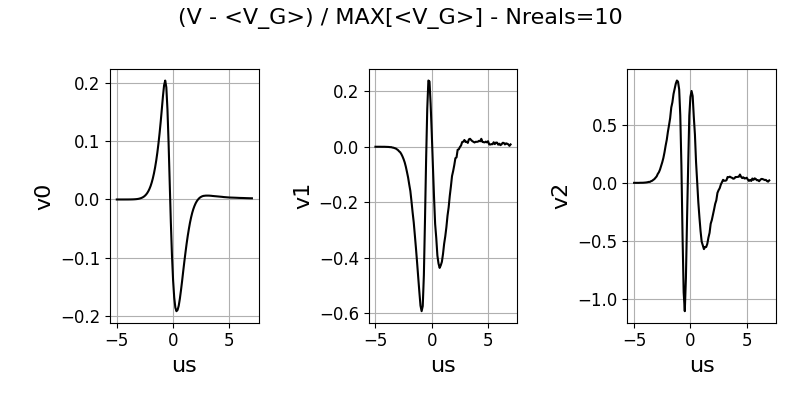

In [18]:
ns = 3 # Number of STD for the plot

fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(8, 4))
fig.suptitle(f'(V - <V_G>) / MAX[<V_G>] - Nreals={nreals}')

ax0.plot(us, (v0_S - mean_v0_Sprime)/np.max(mean_v0_Sprime), color='k')
ax0.set_xlabel('us')
ax0.set_ylabel('v0')
ax0.grid()

ax1.plot(us, (v1_S - mean_v1_Sprime)/np.max(mean_v1_Sprime), color='k')
ax1.set_xlabel('us')
ax1.set_ylabel('v1')
ax1.grid()
#ax1.legend()

ax2.plot(us, (v2_S - mean_v2_Sprime)/np.max(mean_v2_Sprime), color='k')
ax2.set_xlabel('us')
ax2.set_ylabel('v2')
ax2.grid()
#ax2.legend()

fig.tight_layout()